In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/e2e'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [20]:
def plot_bar(filtered_rate1, filtered_rate2, store_cache_layer, req_rate):
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    ax.bar(np.arange(3), filtered_rate1, bar_width, label='0.5:0.5', color=plt.cm.tab20b(0/5), hatch=hatches[0], edgecolor='white')
    ax.bar(np.arange(3)+bar_width, filtered_rate2, bar_width, label='0.25:0.75', color=plt.cm.tab20b(1/5), hatch=hatches[1], edgecolor='white')
    for x, y in zip(np.arange(3), filtered_rate1):
        if y >= 0: ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', rotation=70, fontsize=10)
        else: ax.text(x, y, f'{y:.1f}', ha='center', va='top', rotation=70, fontsize=10)
    for x, y in zip(np.arange(3)+bar_width, filtered_rate2):
        if y >= 0: ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', rotation=70, fontsize=10)
        else: ax.text(x, y, f'{y:.1f}', ha='center', va='top', rotation=70, fontsize=10)
    ax.set_xticklabels(['Throughput', 'TPOT', 'TTFT'], rotation=0)
    ax.set_xticks(np.arange(3)+0.5*bar_width)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylim(min(min(filtered_rate1), min(filtered_rate1))*2.7, max(max(filtered_rate2), max(filtered_rate2))*2.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.legend(loc=(0.1,0.85), ncol=2, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)   
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/{store_cache_layer}_{req_rate}_hfusion.pdf')
    plt.show()     

/tmp/ipykernel_4011214/2671469425.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Throughput', 'TPOT', 'TTFT'], rotation=0)


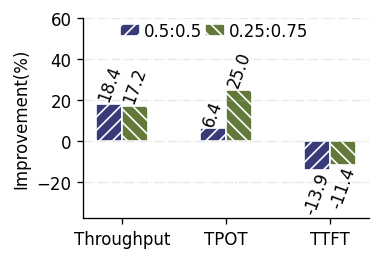

In [21]:
rate1 = [18.4, 6.4, -13.9]
rate2 = [17.2, 25.0, -11.4]
store_cache_layer = 0.2
req_rate = 200
plot_bar(rate1, rate2, store_cache_layer, req_rate)